# Analysing Game Success Probability against Goal Difficulty via Simulation
A small extension that looks at the relationship between move budget and target goal

Now we're  modelling:
$$P(W | \text{number of single colour candies needed to win, moves})$$

We're still only using the simple random agent - every action it takes, it randomly tries to swap two candies

So now think about
$$
f(\text{target, moves}) -> P(\text{win})
$$

This is basically a factorial experiment design, so we have a 2d grid compared to previously where we just had a 1d line

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from match3.game.level import Level, Objective, ObjectiveType
from match3.players.random_player import RandomPlayer
from match3.simulation.simulator import simulate_games

%matplotlib inline

In [8]:
MOVE_RANGE = np.arange(10, 31, 2)

# based on the previous notebook, we can reduce the target to up to 35, since the win rate is already very low at that point
GOAL_RANGE = np.arange(5, 36, 2)


print(f"""{len(MOVE_RANGE)} move counts and {len(GOAL_RANGE)} goal counts will be simulated, 
a total of {len(MOVE_RANGE) * len(GOAL_RANGE)} conditions to simulate.
""")
NUM_GAMES = 100

print(f"Each condition will be simulated {NUM_GAMES} times, for a total of {len(MOVE_RANGE) * len(GOAL_RANGE) * NUM_GAMES} games to simulate.")
BASE_SEED = 42

11 move counts and 16 goal counts will be simulated, 
a total of 176 conditions to simulate.

Each condition will be simulated 100 times, for a total of 17600 games to simulate.


In [ ]:
results_dict = {}

for moves in MOVE_RANGE:
    for goal in GOAL_RANGE:


        level = Level(
            name=f"Collect {goal} Red Candies",
            moves=int(moves),
            objective=Objective(
                type=ObjectiveType.COLLECT,
                target=int(goal),
                candy_type=0,
            ),
        )

        # Use a deterministic calculated seed for reproducibility.
        seed = BASE_SEED + moves * 1000 + goal

        rng = np.random.default_rng(seed)
        player = RandomPlayer(rng)

        results = simulate_games(
            level,
            player,
            n_games=NUM_GAMES,
            rng=rng,
        )

        wins = sum(result.won for result in results)
        win_rate = wins / NUM_GAMES

        results_dict[(moves, goal)] = {
            "wins": wins,
            "games": NUM_GAMES,
            "win_rate": win_rate,
        }

In [10]:
results_df = pd.DataFrame(
    [
        {
            "moves": moves,
            "goal": goal,
            **result,
        }
        for (moves, goal), result in results_dict.items()
    ]
)

results_df.head()

,moves,goal,wins,games,win_rate
0,10,5,84,100,0.84
1,10,7,59,100,0.59
2,10,9,51,100,0.51
3,10,11,21,100,0.21
4,10,13,15,100,0.15


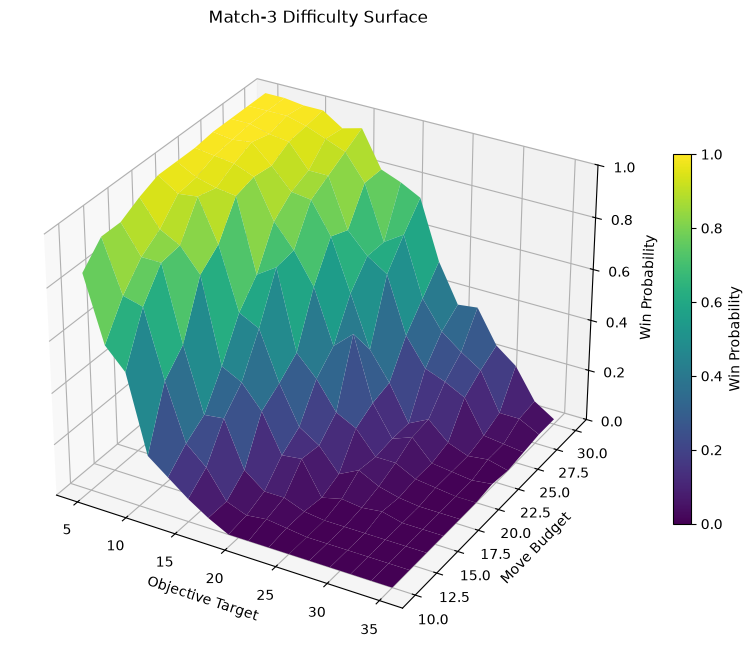

In [15]:
# pivot the dataframe to get in the right shape for a 3d surface plot
surface_df = results_df.pivot(
    index="moves",
    columns="goal",
    values="win_rate",
)

# now extract the X, Y, Z values for the surface plot
X, Y = np.meshgrid(
    surface_df.columns.values,
    surface_df.index.values,
)

Z = surface_df.values

# now plot
fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(111, projection="3d")

surface_plot = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    edgecolor="none",
)

ax.set_xlabel("Objective Target")
ax.set_ylabel("Move Budget")
ax.set_zlabel("Win Probability")

ax.set_zlim(0, 1)

ax.set_title("Match-3 Difficulty Surface")

fig.colorbar(
    surface_plot,
    ax=ax,
    shrink=0.6,
    label="Win Probability",
)

plt.show()

Pretty easy to see that increasing the target lowers the win probability, and increasing the move budget increases the win probability.

Now let's just take the values where we target a 50% win probability: 

_What balance of moves and target do we need to achieve an average 50% win rate?_

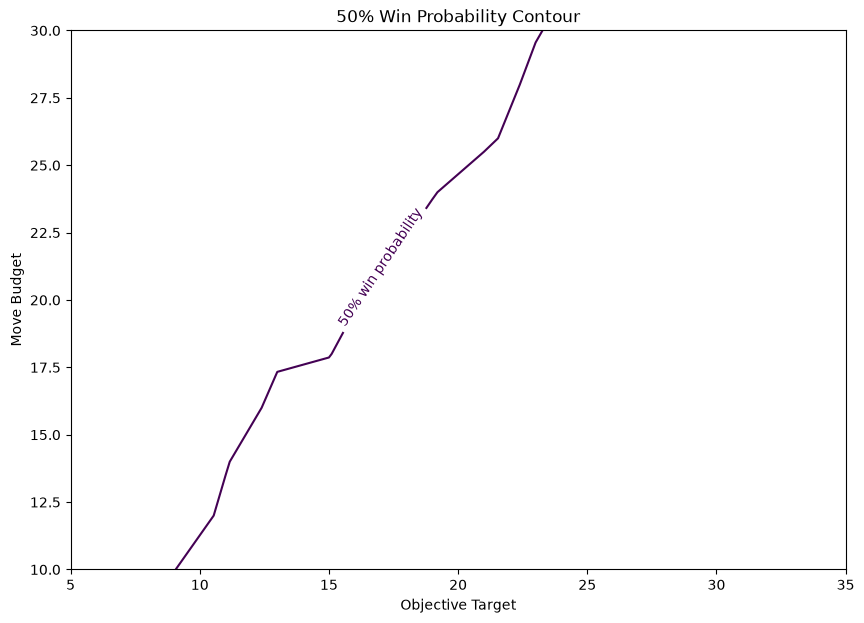

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))

contour = ax.contour(
    X,
    Y,
    Z,
    levels=[0.5],
)

ax.clabel(
    contour,
    inline=True,
    fontsize=10,
    fmt="50%% win probability",
)

ax.set_xlabel("Objective Target")
ax.set_ylabel("Move Budget")
ax.set_title("50% Win Probability Contour")

plt.show()